# Phase 1: Dataset Preparation
## Secure AI-Based Handwritten Text Recognition — Telugu & Hindi

This notebook covers:
1. Install dependencies
2. Download public datasets (IIIT-HWS, Devanagari)
3. Explore and verify the data
4. Augmentation (rotate, blur, skew)
5. Train/Val/Test split (70/15/15)
6. Save prepared dataset

---
## Cell 1 — Install Dependencies

In [ ]:
!pip install -q opencv-python-headless matplotlib scikit-learn albumentations kaggle Pillow tqdm

---
## Cell 2 — Imports

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import shutil
import random
from sklearn.model_selection import train_test_split
import albumentations as A
import json

random.seed(42)
np.random.seed(42)

print('All imports successful!')

All imports successful!


---
## Cell 3 — Download Datasets

We use two public datasets:
- **IIIT-HWS** — Hindi handwritten words (Devanagari script)
- **Telugu Handwritten Characters** — from Kaggle

> **One-time setup:** Add your Kaggle API key in Colab Secrets (key icon on left sidebar) with name `KAGGLE_KEY` and username `KAGGLE_USER`

In [ ]:
#Drive Mount + Path Setup
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

BASE_DIR  = Path('/content/drive/MyDrive/OCR_Project')
RAW_DIR   = BASE_DIR / 'raw'
DATA_DIR  = BASE_DIR / 'processed'
MODEL_DIR = BASE_DIR / 'models'
LOG_DIR   = BASE_DIR / 'logs'
OUT_DIR   = BASE_DIR / 'outputs'

TRAIN_DIR      = DATA_DIR  / 'train'
VAL_DIR        = DATA_DIR  / 'val'
TEST_DIR       = DATA_DIR  / 'test'
CHECKPOINT_DIR = MODEL_DIR / 'checkpoints'
FINAL_DIR      = MODEL_DIR / 'final'

# Telugu, Hindi languages

for d in [RAW_DIR/'hindi', RAW_DIR/'telugu',
          TRAIN_DIR, VAL_DIR, TEST_DIR,
          CHECKPOINT_DIR, FINAL_DIR,
          LOG_DIR, OUT_DIR/'predictions', OUT_DIR/'evaluation']:
    d.mkdir(parents=True, exist_ok=True)

print('✅ Drive mounted!')
print(f'BASE: {BASE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted!
BASE: /content/drive/MyDrive/OCR_Project


In [ ]:
#datasets download in terminal
'''
# ── Setup ────────────────────────────────────
export KAGGLE_USERNAME="SecureDocAI"
export KAGGLE_KEY="KGAT_adbcb6031a65c798af0694ec0ed867d2"

# ── Hindi ────────────────────────────────────
rm -rf /content/drive/MyDrive/OCR_Project/raw/hindi
mkdir -p /content/drive/MyDrive/OCR_Project/raw/hindi
kaggle datasets download -d ujjawalsharma20/hindi-letters \
  -p /content/drive/MyDrive/OCR_Project/raw/hindi
cd /content/drive/MyDrive/OCR_Project/raw/hindi
unzip -q hindi-letters.zip
rm hindi-letters.zip
count=$(find . -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)
echo "✅ Hindi done! → $count images"

# ── Telugu ───────────────────────────────────
rm -rf /content/drive/MyDrive/OCR_Project/raw/telugu
mkdir -p /content/drive/MyDrive/OCR_Project/raw/telugu
kaggle datasets download -d pavankalyand515/data-telugu-handwritten \
  -p /content/drive/MyDrive/OCR_Project/raw/telugu
cd /content/drive/MyDrive/OCR_Project/raw/telugu
unzip -q data-telugu-handwritten.zip
rm data-telugu-handwritten.zip
count=$(find . -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)
echo "✅ Telugu done! → $count images"

# ── Bengali ──────────────────────────────────
rm -rf /content/drive/MyDrive/OCR_Project/raw/bengali
mkdir -p /content/drive/MyDrive/OCR_Project/raw/bengali
kaggle datasets download -d dipuk0506/bangla-character-dataset \
  -p /content/drive/MyDrive/OCR_Project/raw/bengali
cd /content/drive/MyDrive/OCR_Project/raw/bengali
unzip -q bangla-character-dataset.zip
rm bangla-character-dataset.zip
count=$(find . -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)
echo "✅ Bengali done! → $count images"

# ── English ──────────────────────────────────
rm -rf /content/drive/MyDrive/OCR_Project/raw/english
mkdir -p /content/drive/MyDrive/OCR_Project/raw/english
kaggle datasets download -d vaibhao/handwritten-characters \
  -p /content/drive/MyDrive/OCR_Project/raw/english
cd /content/drive/MyDrive/OCR_Project/raw/english
unzip -q handwritten-characters.zip
rm handwritten-characters.zip
count=$(find . -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)
echo "✅ English done! → $count images"

# ── Final Summary ─────────────────────────────
echo ""
echo "── Final Dataset Summary ──"
total=0
for lang in hindi telugu bengali english; do
    count=$(find /content/drive/MyDrive/OCR_Project/raw/$lang \
      -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)
    echo "  $lang : $count images"
    total=$((total + count))
done
echo "  TOTAL : $total images"
echo "───────────────────────────"

'''

<>:15: SyntaxWarning: invalid escape sequence '\('
<>:15: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_2165/2846012084.py:15: SyntaxWarning: invalid escape sequence '\('
  count=$(find . -type f \( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \) | wc -l)


'\n# ── Setup ────────────────────────────────────\nexport KAGGLE_USERNAME="SecureDocAI"\nexport KAGGLE_KEY="KGAT_adbcb6031a65c798af0694ec0ed867d2"\n\n# ── Hindi ────────────────────────────────────\nrm -rf /content/drive/MyDrive/OCR_Project/raw/hindi\nmkdir -p /content/drive/MyDrive/OCR_Project/raw/hindi\nkaggle datasets download -d ujjawalsharma20/hindi-letters   -p /content/drive/MyDrive/OCR_Project/raw/hindi\ncd /content/drive/MyDrive/OCR_Project/raw/hindi\nunzip -q hindi-letters.zip\nrm hindi-letters.zip\ncount=$(find . -type f \\( -name "*.png" -o -name "*.jpg" -o -name "*.jpeg" \\) | wc -l)\necho "✅ Hindi done! → $count images"\n\n# ── Telugu ───────────────────────────────────\nrm -rf /content/drive/MyDrive/OCR_Project/raw/telugu\nmkdir -p /content/drive/MyDrive/OCR_Project/raw/telugu\nkaggle datasets download -d pavankalyand515/data-telugu-handwritten   -p /content/drive/MyDrive/OCR_Project/raw/telugu\ncd /content/drive/MyDrive/OCR_Project/raw/telugu\nunzip -q data-telugu-hand

In [ ]:
#to verify the no.of images
'''
from pathlib import Path

folder = Path('/content/drive/MyDrive/OCR_Project/raw/telugu')  # ← mee path pettu

exts = {'.png', '.jpg', '.jpeg', '.bmp'}

for f in sorted(folder.iterdir()):
    if f.is_dir():
        count = sum(1 for img in f.rglob('*') if img.suffix.lower() in exts)
        print(f"  📁 {f.name}: {count:,} images")
        '''

'\nfrom pathlib import Path\n\nfolder = Path(\'/content/drive/MyDrive/OCR_Project/raw/telugu\')  # ← mee path pettu\n\nexts = {\'.png\', \'.jpg\', \'.jpeg\', \'.bmp\'}\n\nfor f in sorted(folder.iterdir()):\n    if f.is_dir():\n        count = sum(1 for img in f.rglob(\'*\') if img.suffix.lower() in exts)\n        print(f"  📁 {f.name}: {count:,} images")\n        '

In [ ]:
#to verify the no.of images
'''
from pathlib import Path

folder = Path('/content/drive/MyDrive/OCR_Project/raw/hindi')  # ← mee path pettu

exts = {'.png', '.jpg', '.jpeg', '.bmp'}

for f in sorted(folder.iterdir()):
    if f.is_dir():
        count = sum(1 for img in f.rglob('*') if img.suffix.lower() in exts)
        print(f"  📁 {f.name}: {count:,} images")
  '''


'\nfrom pathlib import Path\n\nfolder = Path(\'/content/drive/MyDrive/OCR_Project/raw/hindi\')  # ← mee path pettu\n\nexts = {\'.png\', \'.jpg\', \'.jpeg\', \'.bmp\'}\n\nfor f in sorted(folder.iterdir()):\n    if f.is_dir():\n        count = sum(1 for img in f.rglob(\'*\') if img.suffix.lower() in exts)\n        print(f"  📁 {f.name}: {count:,} images")\n  '

In [ ]:
# Flatten Hindi dataset
'''
import shutil
from pathlib import Path
from tqdm import tqdm

lang_path = Path('/content/drive/MyDrive/OCR_Project/raw/hindi')
exts = {'.jpg', '.jpeg', '.png', '.bmp'}

all_images = [f for f in lang_path.rglob('*')
              if f.suffix.lower() in exts and f.is_file()]
print(f'Hindi: {len(all_images):,} images — flattening...')

for img_path in tqdm(all_images, desc='Hindi'):
    label = img_path.parent.name

    # Already in correct location → skip
    if img_path.parent == lang_path / label:
        continue

    dest_dir = lang_path / label
    dest_dir.mkdir(exist_ok=True)
    dest_path = dest_dir / img_path.name

    # Name conflict fix
    if dest_path.exists():
        dest_path = dest_dir / f'{img_path.stem}_{img_path.parent.parent.name}{img_path.suffix}'

    shutil.move(str(img_path), str(dest_path))

# Empty folders cleanup
for folder in sorted(lang_path.rglob('*'), reverse=True):
    if folder.is_dir() and folder != lang_path:
        try:
            folder.rmdir()  # only removes if empty
        except OSError:
            pass

# Final count
count   = sum(1 for f in lang_path.rglob('*') if f.suffix.lower() in exts)
folders = sum(1 for f in lang_path.iterdir() if f.is_dir())
print(f'\n✅ Hindi: {count:,} images | {folders} class folders')
print(f'Structure: hindi/class_name/image.png ✓')
'''

"\nimport shutil\nfrom pathlib import Path\nfrom tqdm import tqdm\n\nlang_path = Path('/content/drive/MyDrive/OCR_Project/raw/hindi')\nexts = {'.jpg', '.jpeg', '.png', '.bmp'}\n\nall_images = [f for f in lang_path.rglob('*')\n              if f.suffix.lower() in exts and f.is_file()]\nprint(f'Hindi: {len(all_images):,} images — flattening...')\n\nfor img_path in tqdm(all_images, desc='Hindi'):\n    label = img_path.parent.name\n\n    # Already in correct location → skip\n    if img_path.parent == lang_path / label:\n        continue\n\n    dest_dir = lang_path / label\n    dest_dir.mkdir(exist_ok=True)\n    dest_path = dest_dir / img_path.name\n\n    # Name conflict fix\n    if dest_path.exists():\n        dest_path = dest_dir / f'{img_path.stem}_{img_path.parent.parent.name}{img_path.suffix}'\n\n    shutil.move(str(img_path), str(dest_path))\n\n# Empty folders cleanup\nfor folder in sorted(lang_path.rglob('*'), reverse=True):\n    if folder.is_dir() and folder != lang_path:\n        t

---
## Cell 4 — Explore the Data

In [ ]:
#Dataset Summary
exts = {'.png', '.jpg', '.jpeg', '.bmp'}

DATASETS = {
    'hindi'  : 92000,
    'telugu' : 295000,
}

print('── Dataset Summary ───────────────────')
total = 0
for lang, expected in DATASETS.items():
    count = sum(1 for f in (RAW_DIR/lang).rglob('*')
                if f.suffix.lower() in exts)
    folders = sum(1 for f in (RAW_DIR/lang).rglob('*') if f.is_dir())

    print(f'  {lang:10}: {count:,} images | {folders} folders ')
    total += count
print(f'  {"TOTAL":10}: {total:,} images')
print('─────────────────────────────────────')

── Dataset Summary ───────────────────
  hindi     : 92,000 images | 46 folders 
  telugu    : 245,128 images | 557 folders 
  TOTAL     : 337,128 images
─────────────────────────────────────


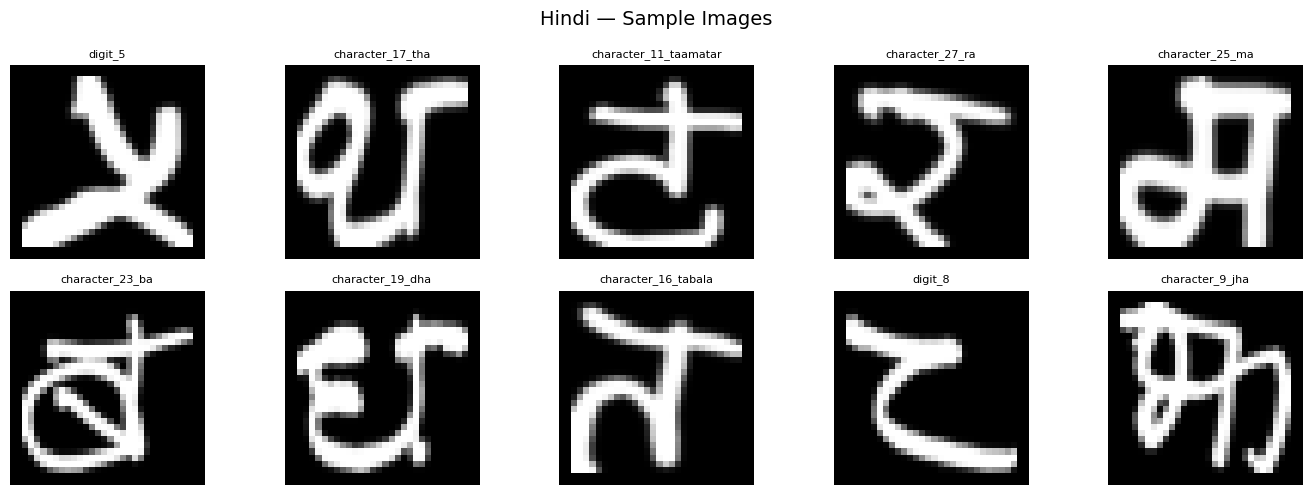

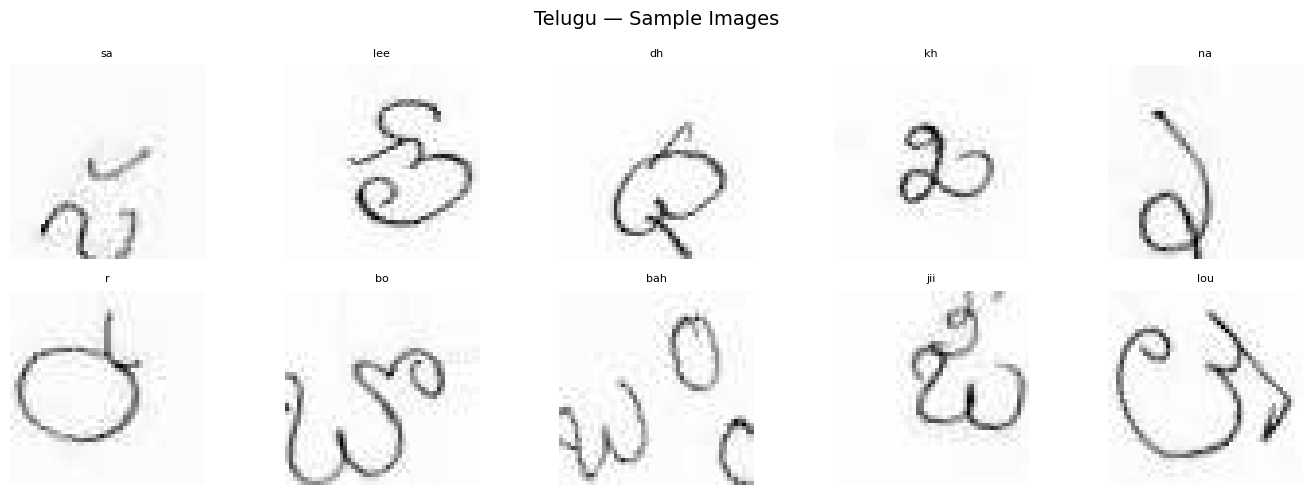

In [ ]:
# Visualize sample images from each language

def show_samples(folder, lang, n=10):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    files = [f for f in Path(folder).rglob('*') if f.suffix.lower() in exts]
    samples = random.sample(files, min(n, len(files)))

    fig, axes = plt.subplots(2, 5, figsize=(14, 5))
    fig.suptitle(f'{lang} — Sample Images', fontsize=14)
    for ax, fpath in zip(axes.flatten(), samples):
        img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(fpath.parent.name, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_samples(RAW_DIR / 'hindi',   'Hindi')
show_samples(RAW_DIR / 'telugu',  'Telugu')

---
## Cell 5 — Preprocessing (Resize + Normalize)

Preprocessed samples — White char on Black bg:


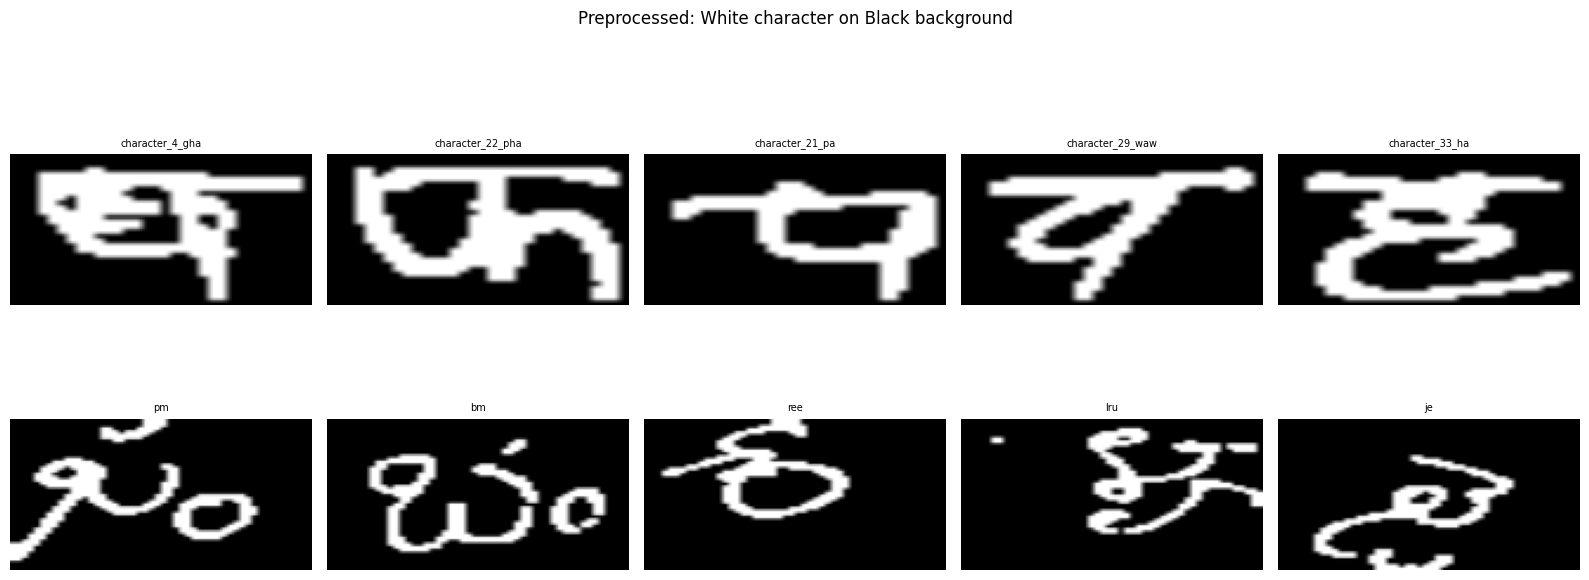

✅ Preprocessing verified!


In [ ]:
# ============================================
# CELL 5 — Advanced Preprocessing + Visualization
# ============================================
IMG_HEIGHT = 64
IMG_WIDTH  = 128

def preprocess_image(img_path, language=None, height=IMG_HEIGHT, width=IMG_WIDTH):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    # Step 1: Denoise lightly
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Step 2: Otsu threshold
    _, img = cv2.threshold(img, 0, 255,
                           cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Step 3: Standardize — white char on black bg
    white = np.sum(img > 127)
    black = np.sum(img <= 127)
    if white > black:
        img = cv2.bitwise_not(img)

    # Step 4: Clean small noise (NO erode — protects thin strokes)
    kernel = np.ones((2, 2), np.uint8)
    img = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    # Step 5: Resize
    img = cv2.resize(img, (width, height),
                     interpolation=cv2.INTER_LINEAR)

    # Step 6: Normalize [0, 1]
    img = img.astype(np.float32) / 255.0

    # Step 7: If image almost empty — return None
    if img.max() < 0.1:
        return None

    return img

# ── Visualize Hindi + Telugu ──────────────────
print('Preprocessed samples — White char on Black bg:')
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for row, (lang, exts_list) in enumerate([
    ('hindi',  ['*.png']),
    ('telugu', ['*.jpg', '*.jpeg']),
]):
    all_files = []
    for ext in exts_list:
        all_files.extend(list((RAW_DIR/lang).rglob(ext)))

    valid = []
    random.shuffle(all_files)
    for fpath in all_files:
        img = preprocess_image(fpath)
        if img is not None:
            valid.append((fpath, img))
        if len(valid) == 5:
            break

    for col, (fpath, img) in enumerate(valid):
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(fpath.parent.name, fontsize=7)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(lang.upper(), fontsize=10,
                            rotation=90, labelpad=40)

plt.suptitle('Preprocessed: White character on Black background',
             fontsize=12)
plt.tight_layout()
plt.show()
print('✅ Preprocessing verified!')

---
## Cell 6 — Data Augmentation

Augmentation simulate real-world handwriting variation:
- **Rotation** — slight tilt (people write at angles)
- **Blur** — simulate low quality scans
- **Elastic distortion** — simulates natural pen strokes
- **Brightness shift** — different lighting conditions

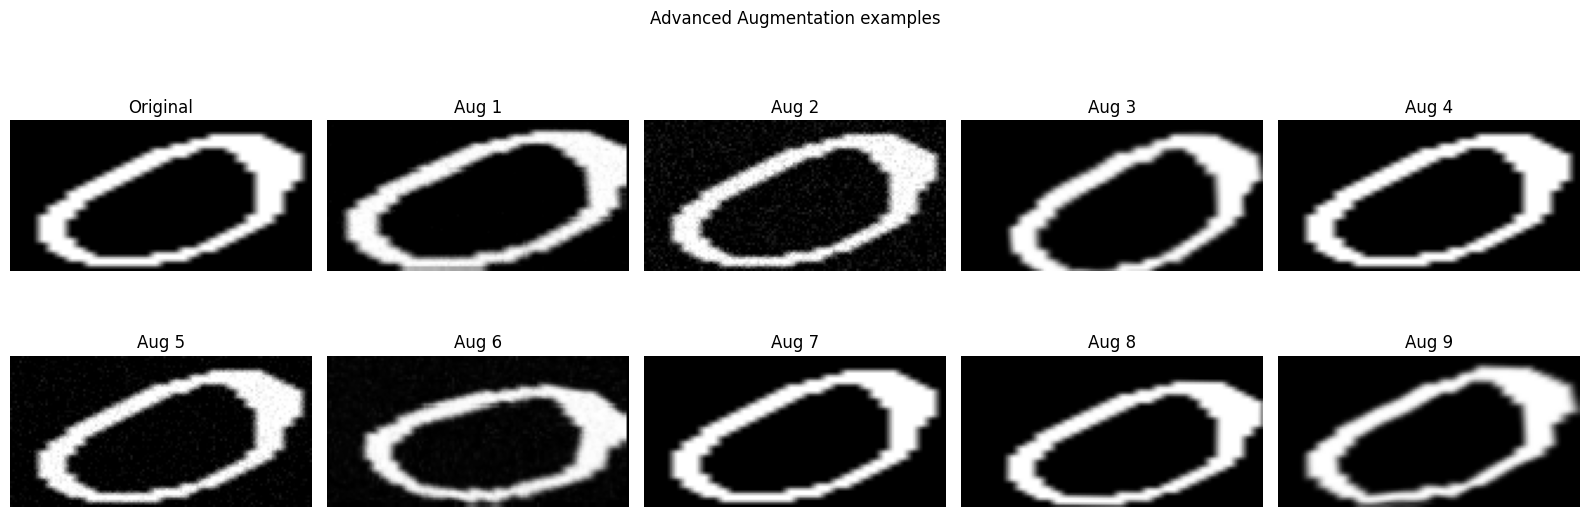

✅ Augmentation ready!


In [ ]:
# ============================================
# CELL 6 — Advanced Augmentation
# ============================================
augment_pipeline = A.Compose([
    A.Rotate(limit=10, p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.9, 1.1),
             rotate=(-10, 10), p=0.4),
    A.Perspective(scale=(0.02, 0.05), p=0.3),

    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MotionBlur(blur_limit=5, p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.3),

    A.GaussNoise(std_range=(0.02, 0.1), p=0.3),

    A.ElasticTransform(alpha=30, sigma=5, p=0.4),
    A.GridDistortion(num_steps=3, distort_limit=0.1, p=0.3),

    A.RandomBrightnessContrast(
        brightness_limit=0.15, contrast_limit=0.15, p=0.4),
])

def augment_image(img_array):
    img_uint8 = (img_array * 255).astype(np.uint8)
    augmented = augment_pipeline(image=img_uint8)['image']
    return augmented.astype(np.float32) / 255.0

# Visualize
lang_files = list((RAW_DIR/'hindi').rglob('*.png'))
valid_orig = None
for f in random.sample(lang_files, min(20, len(lang_files))):
    img = preprocess_image(f)
    if img is not None:
        valid_orig = img
        break

if valid_orig is not None:
    fig, axes = plt.subplots(2, 5, figsize=(16, 6))
    axes[0][0].imshow(valid_orig, cmap='gray')
    axes[0][0].set_title('Original')
    axes[0][0].axis('off')
    for i, ax in enumerate(axes.flatten()[1:], 1):
        aug = augment_image(valid_orig)
        ax.imshow(aug, cmap='gray')
        ax.set_title(f'Aug {i}')
        ax.axis('off')
    plt.suptitle('Advanced Augmentation examples')
    plt.tight_layout()
    plt.show()
print('✅ Augmentation ready!')

---
## Cell 7 — Build Dataset with Labels

In [ ]:
# ============================================
# CELL 7A — Collect Hindi Dataset (Lightweight)
# ============================================
import pickle
import random
from tqdm import tqdm
from pathlib import Path

CACHE_DIR = BASE_DIR / 'cache'
CACHE_DIR.mkdir(exist_ok=True)

def collect_dataset_lightweight(lang_dir, language, augment_factor=2):
    final_cache = CACHE_DIR / f'{language.lower()}_records.pkl'

    if final_cache.exists():
        try:
            print(f'✅ {language} cached — loading records...')
            with open(final_cache, 'rb') as f:
                records = pickle.load(f)
            print(f'✅ {language}: {len(records):,} records loaded!')
            return records
        except (EOFError, pickle.UnpicklingError):
            print(f'⚠️  {language} cache corrupted — re-processing...')
            final_cache.unlink()

    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    lang_path = Path(lang_dir)
    all_images = sorted([f for f in lang_path.rglob('*')
                         if f.suffix.lower() in exts and f.is_file()])

    print(f'{language}: {len(all_images):,} images found')

    records = []
    for img_path in tqdm(all_images, desc=f'Indexing {language}'):
        label = img_path.parent.name
        records.append({
            'path'     : str(img_path),
            'label'    : f'{language}_{label}',
            'language' : language,
            'augmented': False
        })
        for _ in range(augment_factor):
            records.append({
                'path'     : str(img_path),
                'label'    : f'{language}_{label}',
                'language' : language,
                'augmented': True
            })

    with open(final_cache, 'wb') as f:
        pickle.dump(records, f)
    print(f'✅ {language} done! {len(records):,} records cached!')
    return records

# ── Run Hindi ──────────────────────────────────
hindi_data = collect_dataset_lightweight(
    RAW_DIR/'hindi', 'Hindi', augment_factor=2)

print(f'\n✅ Hindi: {len(hindi_data):,} records')
print('Next → Run Cell 7B for Telugu')

✅ Hindi cached — loading records...
✅ Hindi: 276,000 records loaded!

✅ Hindi: 276,000 records
Next → Run Cell 7B for Telugu


In [ ]:
# ============================================
# CELL 7B — Collect Telugu + Merge
# ============================================

telugu_files_count = len([f for f in (RAW_DIR/'telugu').rglob('*')
                           if f.suffix.lower() in {'.jpg','.jpeg','.png','.bmp'}
                           and f.is_file()])
print(f'Telugu: {telugu_files_count:,} images found')

telugu_data = collect_dataset_lightweight(
    RAW_DIR/'telugu', 'Telugu', augment_factor=2)

# ── Combine Hindi + Telugu ─────────────────────
full_dataset = hindi_data + telugu_data
random.shuffle(full_dataset)

print(f'\n── Dataset Summary ──────────────────')
print(f'  Hindi   : {len(hindi_data):,} records')
print(f'  Telugu  : {len(telugu_data):,} records')
print(f'  TOTAL   : {len(full_dataset):,} records')
print(f'─────────────────────────────────────')
print('Next → Run Cell 8 for Train/Val/Test split')

Telugu: 245,128 images found
✅ Telugu cached — loading records...
✅ Telugu: 735,384 records loaded!

── Dataset Summary ──────────────────
  Hindi   : 276,000 records
  Telugu  : 735,384 records
  TOTAL   : 1,011,384 records
─────────────────────────────────────
Next → Run Cell 8 for Train/Val/Test split


---
## Cell 8 — Train / Val / Test Split (70 / 15 / 15)

In [ ]:
# ============================================
# CELL 8 — Train/Val/Test Split
# ============================================
from sklearn.model_selection import train_test_split
import json as json_lib

SPLIT_CACHE = CACHE_DIR / 'split_indices.pkl'

if SPLIT_CACHE.exists():
    print('✅ Split already done — loading...')
    with open(SPLIT_CACHE, 'rb') as f:
        split = pickle.load(f)
    train_data = [full_dataset[i] for i in split['train_idx']]
    val_data   = [full_dataset[i] for i in split['val_idx']]
    test_data  = [full_dataset[i] for i in split['test_idx']]
else:
    labels  = [d['label'] for d in full_dataset]
    indices = list(range(len(full_dataset)))

    train_idx, temp_idx = train_test_split(
        indices, test_size=0.30, stratify=labels, random_state=42)
    temp_labels = [labels[i] for i in temp_idx]
    val_idx, test_idx = train_test_split(
        temp_idx, test_size=0.50, stratify=temp_labels, random_state=42)

    train_data = [full_dataset[i] for i in train_idx]
    val_data   = [full_dataset[i] for i in val_idx]
    test_data  = [full_dataset[i] for i in test_idx]

    with open(SPLIT_CACHE, 'wb') as f:
        pickle.dump({'train_idx': train_idx,
                     'val_idx'  : val_idx,
                     'test_idx' : test_idx}, f)

print(f'── Split Summary ────────────────')
print(f'  Train : {len(train_data):,} ({len(train_data)/len(full_dataset)*100:.1f}%)')
print(f'  Val   : {len(val_data):,}   ({len(val_data)/len(full_dataset)*100:.1f}%)')
print(f'  Test  : {len(test_data):,}  ({len(test_data)/len(full_dataset)*100:.1f}%)')
print(f'─────────────────────────────────')
print('Next → Run Cell 9 to save to disk')

✅ Split already done — loading...
── Split Summary ────────────────
  Train : 707,968 (70.0%)
  Val   : 151,708   (15.0%)
  Test  : 151,708  (15.0%)
─────────────────────────────────
Next → Run Cell 9 to save to disk


---
## Cell 9 — Save Dataset to Drive

In [40]:
# ============================================
# CELL 9 — Save to processed/ (RAM-safe, Resumable, Parallel, Chunked)
# ============================================
import concurrent.futures

SAVE_CHUNK_SIZE = 2000
MAX_WORKERS     = 4
SPLIT_DONE_FLAG = CACHE_DIR / 'split_done.flag'

def save_single_image(args):
    idx, item, output_dir_str = args

    if not isinstance(item, dict) or 'path' not in item:
        return {'idx': idx, 'error': f'Invalid item at idx {idx}'}

    lang  = item['language']
    label = item['label']
    src_path = item['path']

    try:
        img = preprocess_image(src_path)
        if img is None:
            return {'idx': idx, 'error': f'preprocess returned None: {src_path}'}

        if item.get('augmented', False):
            img = augment_image(img)
    except Exception as e:
        return {'idx': idx, 'error': f'idx {idx} ({src_path}): {e}'}

    save_folder = Path(output_dir_str) / lang / label
    save_folder.mkdir(parents=True, exist_ok=True)

    aug_tag   = '_aug' if item.get('augmented', False) else ''
    filename  = f'{idx:07d}{aug_tag}.png'
    save_path = save_folder / filename

    img_uint8 = (img * 255).astype(np.uint8)
    cv2.imwrite(str(save_path), img_uint8)
    del img, img_uint8

    return {
        'idx': idx,
        'file': f'{lang}/{label}/{filename}',
        'label': label, 'language': lang,
        'augmented': item.get('augmented', False)
    }


def save_split_resumable(data, split_name, output_dir):
    split_dir = Path(output_dir) / split_name
    metadata_file = split_dir / 'metadata.json'
    progress_file = CACHE_DIR / f'save_progress_{split_name}.json'
    saved_indices = set()

    if progress_file.exists():
        with open(progress_file) as f:
            progress = json_lib.load(f)
        saved_indices = set(progress['saved_indices'])
        print(f'   {split_name}: {len(saved_indices):,}/{len(data):,} already saved — resuming!')

    remaining_idx = [idx for idx in range(len(data)) if idx not in saved_indices]

    if not remaining_idx:
        print(f'✅ {split_name}: all {len(data):,} images already saved!')
    else:
        print(f'   {split_name}: {len(remaining_idx):,} images remaining to save')

        unique_folders = set()
        for idx in remaining_idx:
            item = data[idx]
            unique_folders.add((item['language'], item['label']))
        for lang, label in unique_folders:
            (split_dir / lang / label).mkdir(parents=True, exist_ok=True)

        total_chunks = (len(remaining_idx) + SAVE_CHUNK_SIZE - 1) // SAVE_CHUNK_SIZE
        errors = []

        meta_f = open(metadata_file, 'a', encoding='utf-8')

        for chunk_idx in range(total_chunks):
            start = chunk_idx * SAVE_CHUNK_SIZE
            end   = min(start + SAVE_CHUNK_SIZE, len(remaining_idx))
            chunk_indices = remaining_idx[start:end]

            args_list = [(idx, data[idx], str(split_dir)) for idx in chunk_indices]

            with concurrent.futures.ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
                for result in tqdm(
                    executor.map(save_single_image, args_list, chunksize=20),
                    total=len(args_list),
                    desc=f'{split_name} chunk {chunk_idx+1}/{total_chunks}'
                ):
                    if 'error' in result:
                        errors.append(result['error'])
                    else:
                        meta_f.write(json_lib.dumps(result) + '\n')
                        saved_indices.add(result['idx'])

            del args_list

            with open(progress_file, 'w') as f:
                json_lib.dump({'saved_indices': list(saved_indices)}, f)

        meta_f.close()

        if errors:
            print(f'\n⚠️  {len(errors)} items had errors (skipped):')
            for e in errors[:5]:
                print(f'   {e}')

    print(f'✅ {split_name}: {len(saved_indices):,}/{len(data):,} images saved')

if not SPLIT_DONE_FLAG.exists():
    save_split_resumable(train_data, 'train', DATA_DIR)
    save_split_resumable(val_data,   'val',   DATA_DIR)
    save_split_resumable(test_data,  'test',  DATA_DIR)
    SPLIT_DONE_FLAG.touch()
    print('\n✅ All splits saved! Flag set.')

In [39]:
save_split_resumable(train_data, 'train', DATA_DIR)
save_split_resumable(val_data,   'val',   DATA_DIR)
save_split_resumable(test_data,  'test',  DATA_DIR)
SPLIT_DONE_FLAG.touch()
print('\n✅ All splits saved! Flag set.')

   train: 707,968/707,968 already saved — resuming!
✅ train: all 707,968 images already saved!
✅ train: 707,968/707,968 images saved
   val: 151,708/151,708 already saved — resuming!
✅ val: all 151,708 images already saved!
✅ val: 151,708/151,708 images saved
   test: 151,706/151,708 already saved — resuming!
   test: 2 images remaining to save


test chunk 1/1: 100%|██████████| 2/2 [00:00<00:00, 125.35it/s]


⚠️  2 items had errors (skipped):
   preprocess returned None: /content/drive/MyDrive/OCR_Project/raw/telugu/guninthamulu/khh/khoo/8.jpg
   preprocess returned None: /content/drive/MyDrive/OCR_Project/raw/telugu/guninthamulu/khh/khoo/8.jpg
✅ test: 151,706/151,708 images saved

✅ All splits saved! Flag set.


---
## Cell 10 — Final Summary + Visualization

In [37]:
# Final verification after resumed save completes
import os

def count_images(split_dir):
    count = 0
    for root, dirs, files in os.walk(split_dir):
        count += sum(1 for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    return count

train_actual = count_images(DATA_DIR / 'train')
val_actual   = count_images(DATA_DIR / 'val')
test_actual  = count_images(DATA_DIR / 'test')

print('-- Final Ground Truth Check --')
print(f'  Train: {train_actual:,}')
print(f'  Val  : {val_actual:,}')
print(f'  Test : {test_actual:,}')
print(f'  Total: {train_actual + val_actual + test_actual:,}')
print()
print(f'  Expected total: {len(full_dataset):,}')
print(f'  Match: {(train_actual + val_actual + test_actual) == len(full_dataset)}')

-- Final Ground Truth Check --
  Train: 709,214
  Val  : 151,708
  Test : 151,706
  Total: 1,012,628

  Expected total: 1,011,384
  Match: False
